In [2]:
import pandas as pd

df = pd.read_csv(r"C:\Users\HP\Downloads\house-prices-advanced-regression-techniques\train.csv")

print(df.shape)
print(df.head())

(1460, 81)
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0   2008  

In [11]:
import pandas as pd

# Select required columns
features = ['GrLivArea', 'BedroomAbvGr', 'FullBath']
target = 'SalePrice'

data = df[features + [target]].copy()

print("Shape:", data.shape)
print("\nMissing values:\n", data.isnull().sum())
print("\nFirst 5 rows:\n")
print(data.head())

Shape: (1460, 4)

Missing values:
 GrLivArea       0
BedroomAbvGr    0
FullBath        0
SalePrice       0
dtype: int64

First 5 rows:

   GrLivArea  BedroomAbvGr  FullBath  SalePrice
0       1710             3         2     208500
1       1262             3         2     181500
2       1786             3         2     223500
3       1717             3         1     140000
4       2198             4         2     250000


In [12]:
from sklearn.model_selection import train_test_split

X = data[features]
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (1168, 3)
Test set shape: (292, 3)


In [5]:
X = data[features]
y = data[target]
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (1168, 3)
Test shape: (292, 3)


In [13]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: 52261.748626944594
Coefficients: [   104.02630701 -26655.16535734  30014.32410896]


In [15]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Predictions
y_pred = model.predict(X_test)

# Metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", round(mse, 2))
print("R2 Score:", round(r2, 4))

# Predict new house
new_house = pd.DataFrame(
    [[2000, 3, 2]],
    columns=['GrLivArea', 'BedroomAbvGr', 'FullBath']
)

predicted_price = model.predict(new_house)

print("\nPredicted Price for 2000 sq ft, 3 bed, 2 bath:")
print(f"${predicted_price[0]:,.2f}")

Mean Squared Error: 2806426667.25
R2 Score: 0.6341

Predicted Price for 2000 sq ft, 3 bed, 2 bath:
$240,377.51


In [8]:
import pandas as pd

coefficients = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_
})

print(coefficients)
print("Intercept:", model.intercept_)

        Feature   Coefficient
0     GrLivArea    104.026307
1  BedroomAbvGr -26655.165357
2      FullBath  30014.324109
Intercept: 52261.748626944594


C:\Users\HP\tf311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


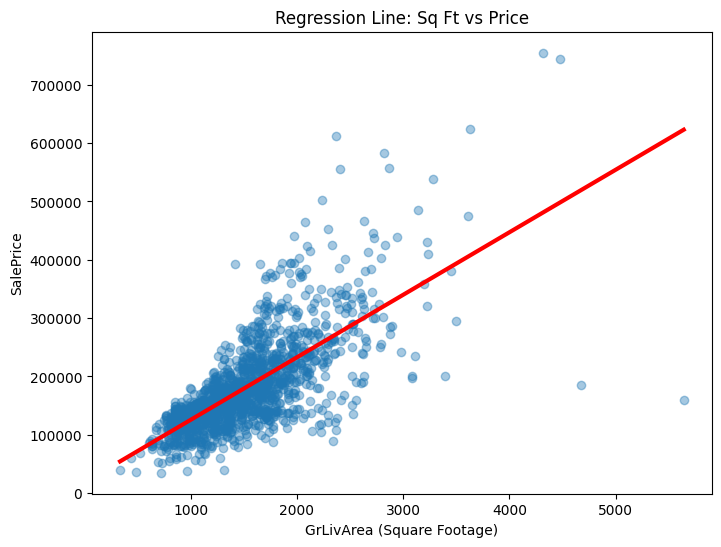

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Use only GrLivArea for visualization
X_single = data[['GrLivArea']]
y_single = data['SalePrice']

from sklearn.linear_model import LinearRegression
model_single = LinearRegression()
model_single.fit(X_single, y_single)

# Create smooth line
x_range = np.linspace(X_single.min(), X_single.max(), 100)
y_line = model_single.predict(x_range)

plt.figure(figsize=(8,6))
plt.scatter(X_single, y_single, alpha=0.4)
plt.plot(x_range, y_line, color='red', linewidth=3)
plt.xlabel("GrLivArea (Square Footage)")
plt.ylabel("SalePrice")
plt.title("Regression Line: Sq Ft vs Price")
plt.show()

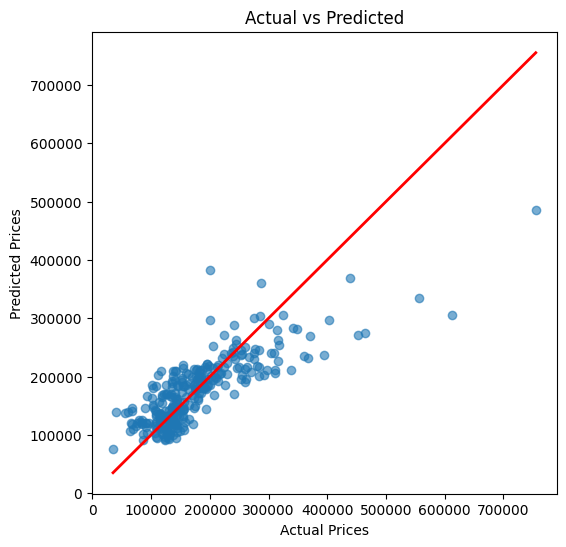

In [17]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.6)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linewidth=2
)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted")
plt.show()